In [1]:
import pandas as pd
import xgboost as xgb
from sklearn.metrics import recall_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss, roc_auc_score, roc_curve
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import precision_score, confusion_matrix
from sklearn.ensemble import ExtraTreesClassifier
import matplotlib.pyplot as plt
import numpy as np
from imblearn.over_sampling import SMOTE


# 1️⃣ Read CSV correctly with semicolon separator
df = pd.read_csv("data.csv", sep=';')

# 2️⃣ Define target and features
target_col = 'Target'  # change if your target has a different name
columns_to_drop = [col for col in ['Application mode', 'Application order', target_col] if col in df.columns]
df = df[df["Target"].isin(["Dropout", "Graduate"])]
df["Target"] = df["Target"].map({"Dropout": 1, "Graduate": 0}) 
X = df.drop(columns=columns_to_drop)
y = df[target_col]

# 3️⃣ Train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 4️⃣ Apply SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 5️⃣ Scale features to avoid data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)  # fit only on train
X_test_scaled = scaler.transform(X_test)            # transform test only

# ✅ Now ready for model training
print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)
print("Train class distribution after SMOTE:\n", pd.Series(y_train_res).value_counts())


Train shape: (3534, 34)
Test shape: (726, 34)
Train class distribution after SMOTE:
 1    1767
0    1767
Name: Target, dtype: int64


In [2]:


knn = KNeighborsClassifier()

param_grid = {
    'n_neighbors': list(range(1, 21)),  # 1 to 20 neighbors
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', return_train_score=True)
grid.fit(X_train_scaled, y_train_res)
print("Best KNN params:", grid.best_params_)
best_knn = grid.best_estimator_

Best KNN params: {'metric': 'manhattan', 'n_neighbors': 10, 'weights': 'distance'}


In [3]:
results = pd.DataFrame(grid.cv_results_)

In [4]:
best_knn.fit(X_train_scaled, y_train_res)

# -----------------------------
# 5. Predictions
# -----------------------------
y_train_pred = best_knn.predict(X_train_scaled)
y_test_pred = best_knn.predict(X_test_scaled)

# -----------------------------
# 6. Metrics: Accuracy, Precision, Recall
# -----------------------------
print("Train Accuracy:", accuracy_score(y_train_res, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

print("\nTrain Precision & Recall:")
print("Precision:", precision_score(y_train_res, y_train_pred, average='weighted'))
print("Recall:", recall_score(y_train_res, y_train_pred, average='weighted'))

print("\nTest Precision & Recall:")
print("Precision:", precision_score(y_test, y_test_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_test_pred, average='weighted'))

# -----------------------------
# 7. Confusion Matrices
# -----------------------------
print("\nTrain Confusion Matrix:")
print(confusion_matrix(y_train_res, y_train_pred))


Train Accuracy: 1.0
Test Accuracy: 0.8966942148760331

Train Precision & Recall:
Precision: 1.0
Recall: 1.0

Test Precision & Recall:
Precision: 0.8999671570947922
Recall: 0.8966942148760331

Train Confusion Matrix:
[[1767    0]
 [   0 1767]]


KNN Train Log Loss: 2.220446049250313e-16
KNN Test Log Loss: 0.39859507160493984
KNN Train AUC: 1.0
KNN Test AUC: 0.9473981900452488


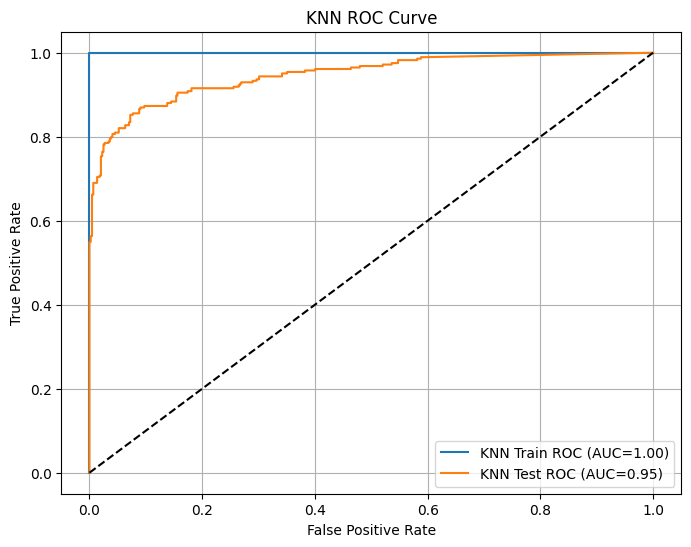

In [5]:
# Log Loss (directly)
print("KNN Train Log Loss:", log_loss(y_train_res, best_knn.predict_proba(X_train_scaled)))
print("KNN Test Log Loss:", log_loss(y_test, best_knn.predict_proba(X_test_scaled)))

# AUC (directly)
print("KNN Train AUC:", roc_auc_score(y_train_res, best_knn.predict_proba(X_train_scaled)[:,1]))
print("KNN Test AUC:", roc_auc_score(y_test, best_knn.predict_proba(X_test_scaled)[:,1]))

# ROC Curve
plt.figure(figsize=(8,6))
fpr_train, tpr_train, _ = roc_curve(y_train_res, best_knn.predict_proba(X_train_scaled)[:,1])
fpr_test, tpr_test, _ = roc_curve(y_test, best_knn.predict_proba(X_test_scaled)[:,1])
plt.plot(fpr_train, tpr_train, label=f'KNN Train ROC (AUC={roc_auc_score(y_train_res, best_knn.predict_proba(X_train_scaled)[:,1]):.2f})')
plt.plot(fpr_test, tpr_test, label=f'KNN Test ROC (AUC={roc_auc_score(y_test, best_knn.predict_proba(X_test_scaled)[:,1]):.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("KNN ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


In [6]:
lr = LogisticRegression(max_iter=1000)
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],  # l1 requires solver='liblinear'
    'solver': ['lbfgs']
}

grid_lr = GridSearchCV(lr, param_grid_lr, cv=5, scoring='accuracy')
grid_lr.fit(X_train_scaled, y_train_res)

best_lr = grid_lr.best_estimator_
y_train_pred_lr = best_lr.predict(X_train_scaled)
y_test_pred_lr = best_lr.predict(X_test_scaled)

print("=== Logistic Regression ===")
print("Best Params:", grid_lr.best_params_)
print("Train Accuracy:", accuracy_score(y_train_res, y_train_pred_lr))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_lr))
print("Train Precision:", precision_score(y_train_res, y_train_pred_lr, average='weighted'))
print("Train Recall:", recall_score(y_train_res, y_train_pred_lr, average='weighted'))
print("Test Precision:", precision_score(y_test, y_test_pred_lr, average='weighted'))
print("Test Recall:", recall_score(y_test, y_test_pred_lr, average='weighted'))
print("Train Confusion Matrix:\n", confusion_matrix(y_train_res, y_train_pred_lr))
print("Test Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_lr))

=== Logistic Regression ===
Best Params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Train Accuracy: 0.9105829088851161
Test Accuracy: 0.931129476584022
Train Precision: 0.9117481458689114
Train Recall: 0.9105829088851161
Test Precision: 0.9316906663550298
Test Recall: 0.931129476584022
Train Confusion Matrix:
 [[1656  111]
 [ 205 1562]]
Test Confusion Matrix:
 [[413  29]
 [ 21 263]]


LogReg Train Log Loss: 0.2270656705131132
LogReg Test Log Loss: 0.1990415042039579
LogReg Train AUC: 0.9634162628763705
LogReg Test AUC: 0.9724682939264546


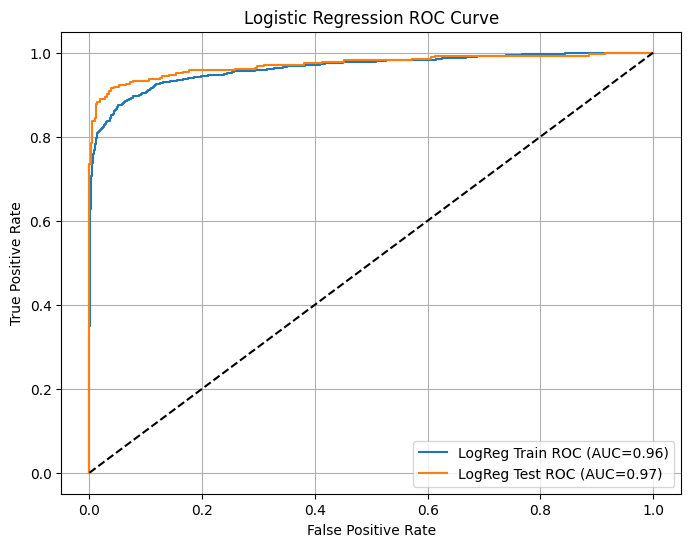

In [7]:
# Log Loss (directly)
print("LogReg Train Log Loss:", log_loss(y_train_res, best_lr.predict_proba(X_train_scaled)))
print("LogReg Test Log Loss:", log_loss(y_test, best_lr.predict_proba(X_test_scaled)))

# AUC (directly)
print("LogReg Train AUC:", roc_auc_score(y_train_res, best_lr.predict_proba(X_train_scaled)[:,1]))
print("LogReg Test AUC:", roc_auc_score(y_test, best_lr.predict_proba(X_test_scaled)[:,1]))

# ROC Curve
plt.figure(figsize=(8,6))
fpr_train, tpr_train, _ = roc_curve(y_train_res, best_lr.predict_proba(X_train_scaled)[:,1])
fpr_test, tpr_test, _ = roc_curve(y_test, best_lr.predict_proba(X_test_scaled)[:,1])
plt.plot(fpr_train, tpr_train, label=f'LogReg Train ROC (AUC={roc_auc_score(y_train_res, best_lr.predict_proba(X_train_scaled)[:,1]):.2f})')
plt.plot(fpr_test, tpr_test, label=f'LogReg Test ROC (AUC={roc_auc_score(y_test, best_lr.predict_proba(X_test_scaled)[:,1]):.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


In [8]:
svm = SVC(random_state=42)
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(svm, param_grid_svm, cv=5, scoring='accuracy')
grid_svm.fit(X_train_scaled, y_train_res)

best_svm = grid_svm.best_estimator_
y_train_pred_svm = best_svm.predict(X_train_scaled)
y_test_pred_svm = best_svm.predict(X_test_scaled)

print("\n=== SVM ===")
print("Best Params:", grid_svm.best_params_)
print("Train Accuracy:", accuracy_score(y_train_res, y_train_pred_svm))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_svm))
print("Train Precision:", precision_score(y_train_res, y_train_pred_svm, average='weighted'))
print("Train Recall:", recall_score(y_train_res, y_train_pred_svm, average='weighted'))
print("Test Precision:", precision_score(y_test, y_test_pred_svm, average='weighted'))
print("Test Recall:", recall_score(y_test, y_test_pred_svm, average='weighted'))
print("Train Confusion Matrix:\n", confusion_matrix(y_train_res, y_train_pred_svm))
print("Test Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_svm))


=== SVM ===
Best Params: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Train Accuracy: 0.9637804187889077
Test Accuracy: 0.9132231404958677
Train Precision: 0.9646858919743726
Train Recall: 0.9637804187889077
Test Precision: 0.9137621896501126
Test Recall: 0.9132231404958677
Train Confusion Matrix:
 [[1742   25]
 [ 103 1664]]
Test Confusion Matrix:
 [[407  35]
 [ 28 256]]


SVM Train Log Loss: 0.12211678339886947
SVM Test Log Loss: 0.22800726396097806
SVM Train AUC: 0.9900643406167716
SVM Test AUC: 0.9638407367280607


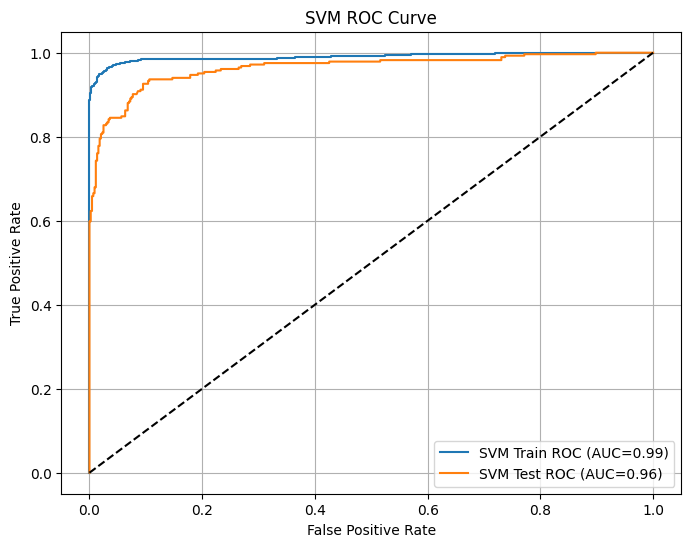

In [9]:
# Ensure probability=True
best_svm.probability = True
best_svm.fit(X_train_scaled, y_train_res)

# Log Loss (directly)
print("SVM Train Log Loss:", log_loss(y_train_res, best_svm.predict_proba(X_train_scaled)))
print("SVM Test Log Loss:", log_loss(y_test, best_svm.predict_proba(X_test_scaled)))

# AUC (directly)
print("SVM Train AUC:", roc_auc_score(y_train_res, best_svm.predict_proba(X_train_scaled)[:,1]))
print("SVM Test AUC:", roc_auc_score(y_test, best_svm.predict_proba(X_test_scaled)[:,1]))

# ROC Curve
plt.figure(figsize=(8,6))
fpr_train, tpr_train, _ = roc_curve(y_train_res, best_svm.predict_proba(X_train_scaled)[:,1])
fpr_test, tpr_test, _ = roc_curve(y_test, best_svm.predict_proba(X_test_scaled)[:,1])
plt.plot(fpr_train, tpr_train, label=f'SVM Train ROC (AUC={roc_auc_score(y_train_res, best_svm.predict_proba(X_train_scaled)[:,1]):.2f})')
plt.plot(fpr_test, tpr_test, label=f'SVM Test ROC (AUC={roc_auc_score(y_test, best_svm.predict_proba(X_test_scaled)[:,1]):.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


In [10]:
rf = RandomForestClassifier()
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='accuracy')
grid_rf.fit(X_train_scaled, y_train_res)

best_rf = grid_rf.best_estimator_
y_train_pred_rf = best_rf.predict(X_train_scaled)
y_test_pred_rf = best_rf.predict(X_test_scaled)

print("\n=== Random Forest ===")
print("Best Params:", grid_rf.best_params_)
print("Train Accuracy:", accuracy_score(y_train_res, y_train_pred_rf))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_rf))
print("Train Precision:", precision_score(y_train_res, y_train_pred_rf, average='weighted'))
print("Train Recall:", recall_score(y_train_res, y_train_pred_rf, average='weighted'))
print("Test Precision:", precision_score(y_test, y_test_pred_rf, average='weighted'))
print("Test Recall:", recall_score(y_test, y_test_pred_rf, average='weighted'))
print("Train Confusion Matrix:\n", confusion_matrix(y_train_res, y_train_pred_rf))
print("Test Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred_rf))




=== Random Forest ===
Best Params: {'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Train Accuracy: 1.0
Test Accuracy: 0.9338842975206612
Train Precision: 1.0
Train Recall: 1.0
Test Precision: 0.9338147273350369
Test Recall: 0.9338842975206612
Train Confusion Matrix:
 [[1767    0]
 [   0 1767]]
Test Confusion Matrix:
 [[419  23]
 [ 25 259]]


Train Log Loss: 2.220446049250313e-16
Test Log Loss: 0.21941036830847385
Train AUC: 1.0
Test AUC: 0.970966636925626


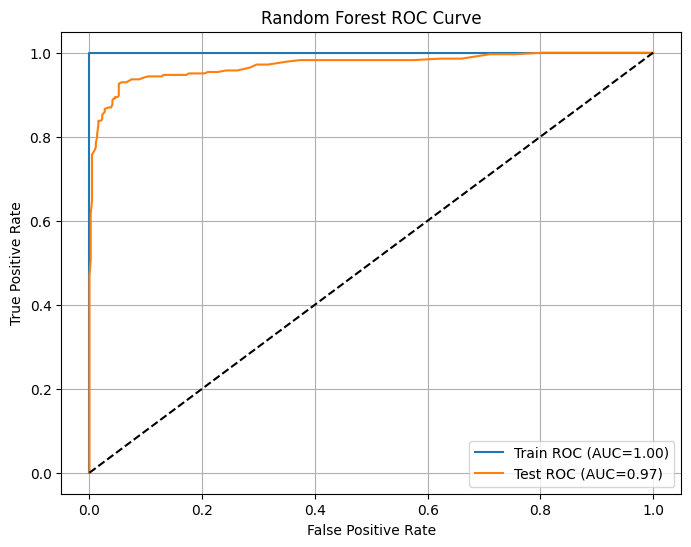

In [11]:


# Log Loss (directly)
print("Train Log Loss:", log_loss(y_train_res, best_rf.predict_proba(X_train_scaled)))
print("Test Log Loss:", log_loss(y_test, best_rf.predict_proba(X_test_scaled)))

# AUC (directly)
print("Train AUC:", roc_auc_score(y_train_res, best_rf.predict_proba(X_train_scaled)[:,1]))
print("Test AUC:", roc_auc_score(y_test, best_rf.predict_proba(X_test_scaled)[:,1]))

# ROC Curve
plt.figure(figsize=(8,6))
fpr_train, tpr_train, _ = roc_curve(y_train_res, best_rf.predict_proba(X_train_scaled)[:,1])
fpr_test, tpr_test, _ = roc_curve(y_test, best_rf.predict_proba(X_test_scaled)[:,1])
plt.plot(fpr_train, tpr_train, label=f'Train ROC (AUC={roc_auc_score(y_train_res, best_rf.predict_proba(X_train_scaled)[:,1]):.2f})')
plt.plot(fpr_test, tpr_test, label=f'Test ROC (AUC={roc_auc_score(y_test, best_rf.predict_proba(X_test_scaled)[:,1]):.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

Fitting 5 folds for each of 192 candidates, totalling 960 fits


C:\Users\sai bharath\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\sklearn.py:885: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 150, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 0.8}
Train Log Loss: 0.09599776357522675
Test Log Loss: 0.19551559834629095
Train AUC: 0.9973304841416026
Test AUC: 0.9708351921483652


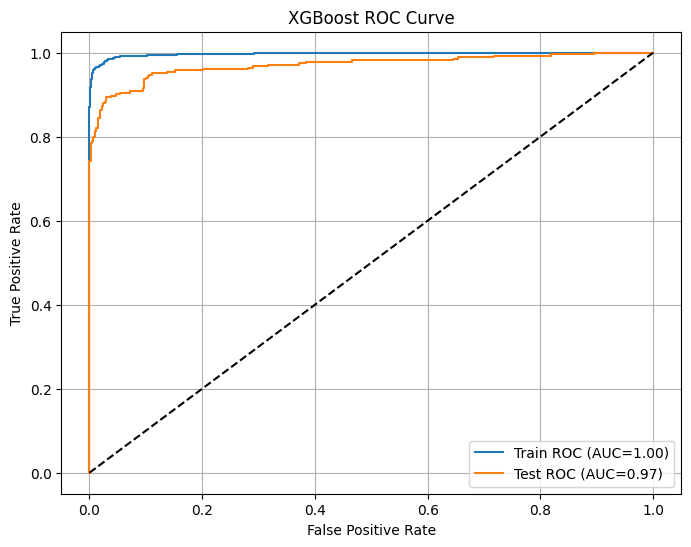

In [12]:

param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [3, 5],           # reduced depth
    'learning_rate': [0.05, 0.1],  # smaller learning rate
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0, 1],           # L1 regularization
    'reg_lambda': [1, 5]           # L2 regularization
}

import xgboost as xgb

# Correct: create the model once
xgb_clf = xgb.XGBClassifier(
    max_depth=5,
    n_estimators=150,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1,
    reg_lambda=1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Fit the model
xgb_clf.fit(X_train_scaled, y_train_res)

# Use the fitted model for predictions and evaluation
y_pred = xgb_clf.predict(X_test_scaled)
y_proba = xgb_clf.predict_proba(X_test_scaled)


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_xgb = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    scoring='recall',       # focus on recall
    cv=skf,
    n_jobs=-1,
    verbose=1
)


grid_xgb.fit(
    X_train_scaled, y_train_res,
    eval_set=[(X_test_scaled, y_test)],
    early_stopping_rounds=20,
    verbose=False
)

best_xgb = grid_xgb.best_estimator_
print("Best Params:", grid_xgb.best_params_)

# ------------------ Direct Evaluation ------------------
print("Train Log Loss:", log_loss(y_train_res, best_xgb.predict_proba(X_train_scaled)))
print("Test Log Loss:", log_loss(y_test, best_xgb.predict_proba(X_test_scaled)))

print("Train AUC:", roc_auc_score(y_train_res, best_xgb.predict_proba(X_train_scaled)[:,1]))
print("Test AUC:", roc_auc_score(y_test, best_xgb.predict_proba(X_test_scaled)[:,1]))

# ROC Curve
plt.figure(figsize=(8,6))
fpr_train, tpr_train, _ = roc_curve(y_train_res, best_xgb.predict_proba(X_train_scaled)[:,1])
fpr_test, tpr_test, _ = roc_curve(y_test, best_xgb.predict_proba(X_test_scaled)[:,1])
plt.plot(fpr_train, tpr_train, label=f'Train ROC (AUC={roc_auc_score(y_train_res, best_xgb.predict_proba(X_train_scaled)[:,1]):.2f})')
plt.plot(fpr_test, tpr_test, label=f'Test ROC (AUC={roc_auc_score(y_test, best_xgb.predict_proba(X_test_scaled)[:,1]):.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
y_train_pred = best_xgb.predict(X_train_scaled)
y_test_pred = best_xgb.predict(X_test_scaled)

print("Train Recall:", recall_score(y_train_res, y_train_pred))
print("Test Recall:", recall_score(y_test, y_test_pred))




print("Train Precision:", precision_score(y_train_res, y_train_pred))
print("Test Precision:", precision_score(y_test, y_test_pred))

print("Train Confusion Matrix:\n", confusion_matrix(y_train_res, y_train_pred))
print("Test Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))



Train Recall: 0.9598189020939445
Test Recall: 0.9049295774647887
Train Precision: 0.9923932124049152
Test Precision: 0.8986013986013986
Train Confusion Matrix:
 [[1754   13]
 [  71 1696]]
Test Confusion Matrix:
 [[413  29]
 [ 27 257]]
